### Protein search ISS only from 25  to 33 - 3/03/22

In [1]:
# import packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import xgboost as xgb
import matplotlib.patches as mpatches
from matplotlib.font_manager import FontProperties
import itertools
from sklearn.model_selection import train_test_split
%config Completer.use_jedi = False
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import plot_roc_curve
from sklearn.metrics import auc, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support
import shap

In [2]:
np.__version__

'1.22.4'

In [3]:
from platform import python_version
print(python_version())

3.8.13


In [4]:
#load data
clin = pd.read_csv('clin_ready.csv', header = 0, index_col=0)
prot = pd.read_csv('raw_data_proteins_filtered.csv',header = 0, index_col = 0)
prot_list = pd.read_csv('prot_filtered.csv', header = 0, index_col=0)

prot = prot.filter(prot_list.iloc[:,0], axis = 1)
prot = prot.drop(labels = [1578], axis = 0)
clin = clin.drop(labels = [1578], axis = 0)
prot.shape

(414, 4979)

In [6]:
# scale all 
X = StandardScaler().fit_transform(prot)
df_scaled = pd.DataFrame(X)
df_scaled.columns = prot.columns
df_scaled.index = prot.index

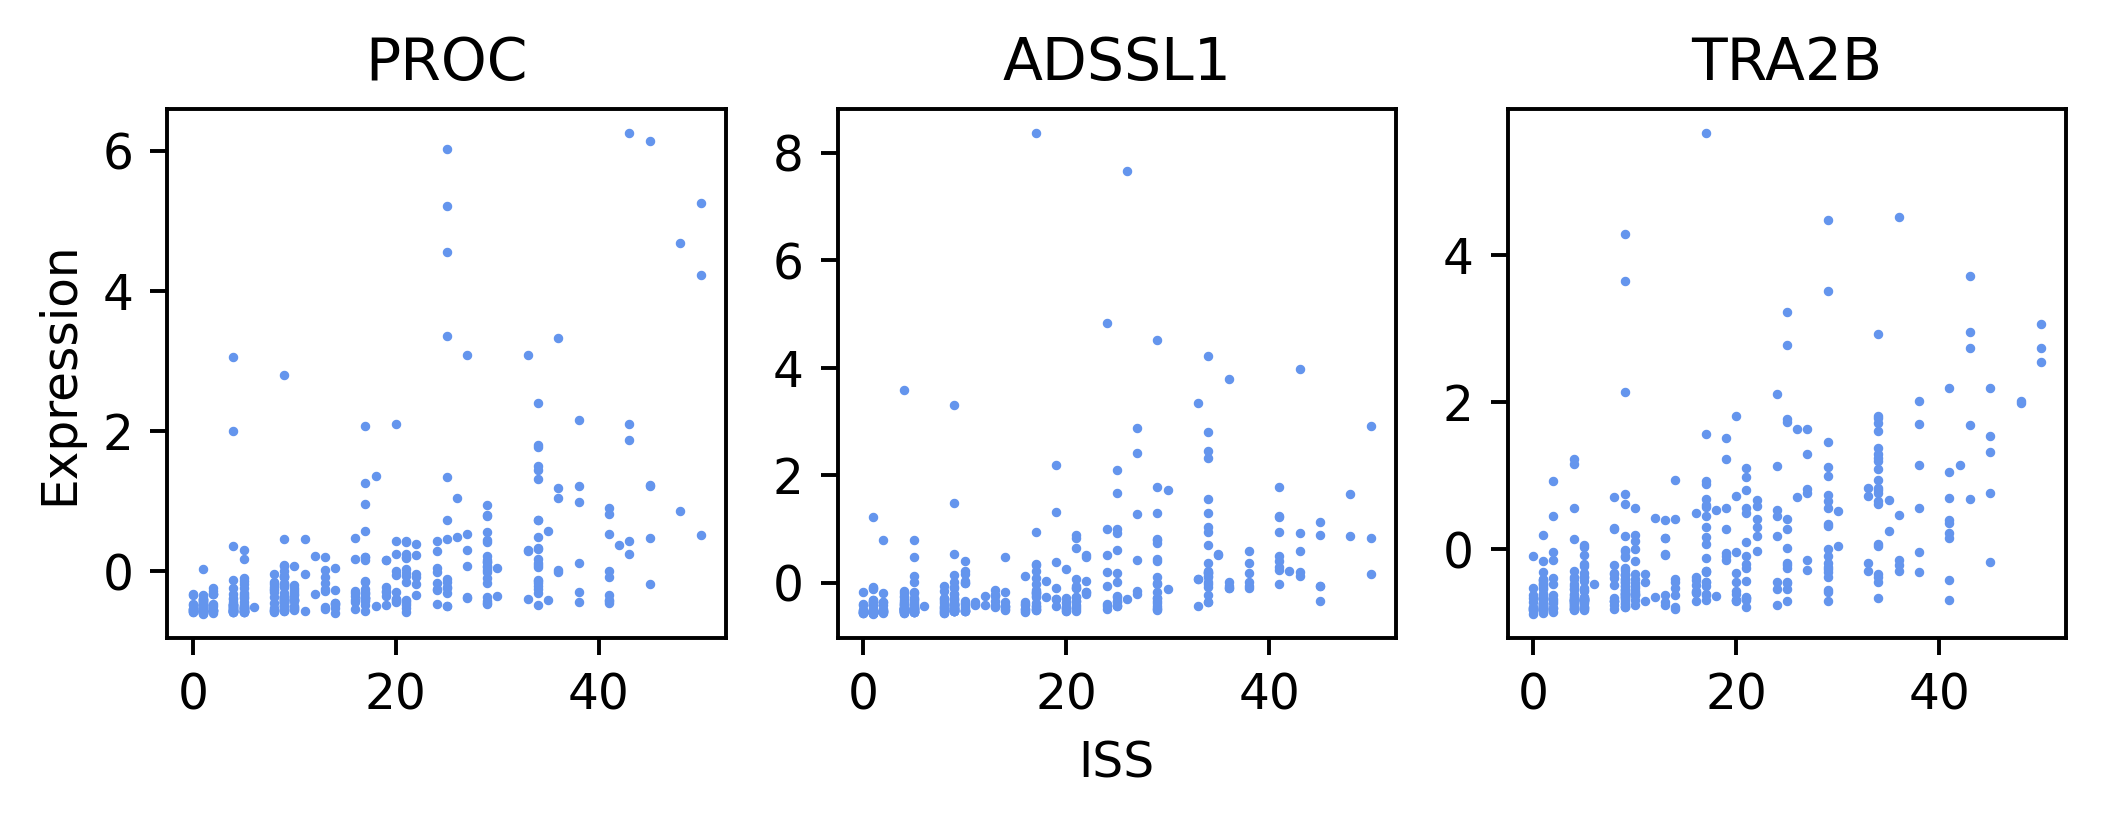

In [8]:
fig = plt.figure(figsize=(7, 2), dpi=350)
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, 0])
ax.scatter(clin.iss, df_scaled['PROC.3758.68'], s=0.9, c = 'cornflowerblue')
ax.set_title('PROC')
ax.set_ylabel('Expression')

ax = fig.add_subplot(gs[0, 1])
ax.scatter(clin.iss, df_scaled['ADSSL1.13998.26'], s=0.9, c = 'cornflowerblue')
ax.set_title('ADSSL1')
ax.set_xlabel('ISS')

ax = fig.add_subplot(gs[0, 2])
ax.scatter(clin.iss, df_scaled['TRA2B.12373.73'], s=0.9, c = 'cornflowerblue')
ax.set_title('TRA2B')

plt.show()


In [9]:
y = clin['iss']

# split in train and test 
X_train, X_test, y_train, y_test = train_test_split(prot, y, shuffle = True, test_size = 0.3, random_state = 132)   #132     

# scale each part independently
scaler = StandardScaler().fit(X_train)
X_train_ = scaler.transform(X_train) #ndarray
X_train_df = pd.DataFrame(X_train_)
X_train_df.columns = X_train.columns
X_train_df.index = X_train.index

#apply the same scaler to test and val dataset
X_test_ = scaler.transform(X_test)
X_test_df= pd.DataFrame(X_test_)
X_test_df.columns = X_test.columns
X_test_df.index = X_test.index

print("X_train shape", X_train.shape)
print("X_test shape", X_test.shape)

X_train shape (289, 4979)
X_test shape (125, 4979)


In [10]:
# extract the features that are important at each round
min_ = 24
max_ = 34
scores =[]
target =[]

for n in range(min_, max_):
    
    X_train = X_train_df
    X_test = X_test_df
    
    y_tr = [1 if i >n else 0 for i in y_train]
    y_te = [1 if i >n else 0 for i in y_test]
    pos_weight = np.bincount(y_tr)[0]/np.bincount(y_tr)[1]
    
    dtrain = xgb.DMatrix(X_train, label= y_tr)
    dtest = xgb.DMatrix(X_test, label=y_te)
    param = {'max_depth': 1, 'eta': 0.2, 'objective': 'binary:logistic', 'scale_pos_weight':pos_weight}
    param['eval_metric'] = 'auc'
    num_round = 35 
    evallist = [(dtest, 'eval'), (dtrain, 'train')]
    progress = {}
    bst = xgb.train(param, dtrain, num_round, evallist, evals_result = progress, verbose_eval=0, early_stopping_rounds=25)     
    
    # get the top proteins for each
    score = bst.get_fscore() #how many  times a feature is used for a split
    
    top_prot=[]
    for key, value in score.items():
        #print(score.items())
        if value > 1: #MORE THAN ONE SPLIT
            top_prot.append(key) #key.split(".")[0]
    
    scores.append(top_prot)

print("Done!")

Done!


In [11]:
# 32 random state
# len of each proteins list
for i in scores:
    print(len(i))

2
6
5
7
7
6
5
5
5
7


In [12]:
# make a table of the proteins
selected_prot = pd.DataFrame(scores)
selected_prot.columns = ["Prot1","Prot2", "Prot3", "Prot4", "Prot5", "Prot6", "Prot7"]
selected_prot.index = ["Threshold at 24","Threshold at 25", "Threshold at 26", "Threshold at 27",
                       "Threshold at 28", "Threshold at 29", "Threshold at 30", "Threshold at 31", "Threshold at 32", "Threshold at 33"]
#selected_prot.to_csv('/Users/smasarone/Desktop/table_prots.csv') 
selected_prot

,Prot1,Prot2,Prot3,Prot4,Prot5,Prot6,Prot7
Threshold at 24,PROC.3758.68,HIST1H1C.2987.37,None,None,None,None,None
Threshold at 25,ASB9.19601.15,CPLX2.15321.8,HIST2H2BE.14143.8,AFM.4763.31,PTH.5954.62,SERPINA7.2706.69,None
Threshold at 26,ASB9.19601.15,CPLX2.15321.8,AFM.4763.31,PTH.5954.62,RAP2A.9885.41,None,None
Threshold at 27,ADSSL1.13998.26,ASB9.19601.15,CPLX2.15321.8,PTH.5954.62,FCN2.13717.15,RAP2A.9885.41,ADSL.5023.23
Threshold at 28,ADSSL1.13998.26,ASB9.19601.15,CPLX2.15321.8,PTH.5954.62,FCN2.13717.15,RAP2A.9885.41,ADSL.5023.23
Threshold at 29,ADSSL1.13998.26,CLIC5.12475.48,ALDH2.18381.16,PLTP.15475.4,CLEC1B.4332.6,TGM3.4471.50,None
Threshold at 30,ADSSL1.13998.26,CLIC5.12475.48,CCL22.3508.78,PLTP.15475.4,IL1RL1.4234.8,None,None
Threshold at 31,ADSSL1.13998.26,CLIC5.12475.48,CCL22.3508.78,PLTP.15475.4,IL1RL1.4234.8,None,None
Threshold at 32,ADSSL1.13998.26,CLIC5.12475.48,CCL22.3508.78,PLTP.15475.4,IL1RL1.4234.8,None,None
Threshold at 33,ADSSL1.13998.26,UBA2.12500.88,SERPINF1.9211.19,AFM.4763.31,IL19.3035.80,PDLIM4.12387.7,CLEC1B.4332.6


Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


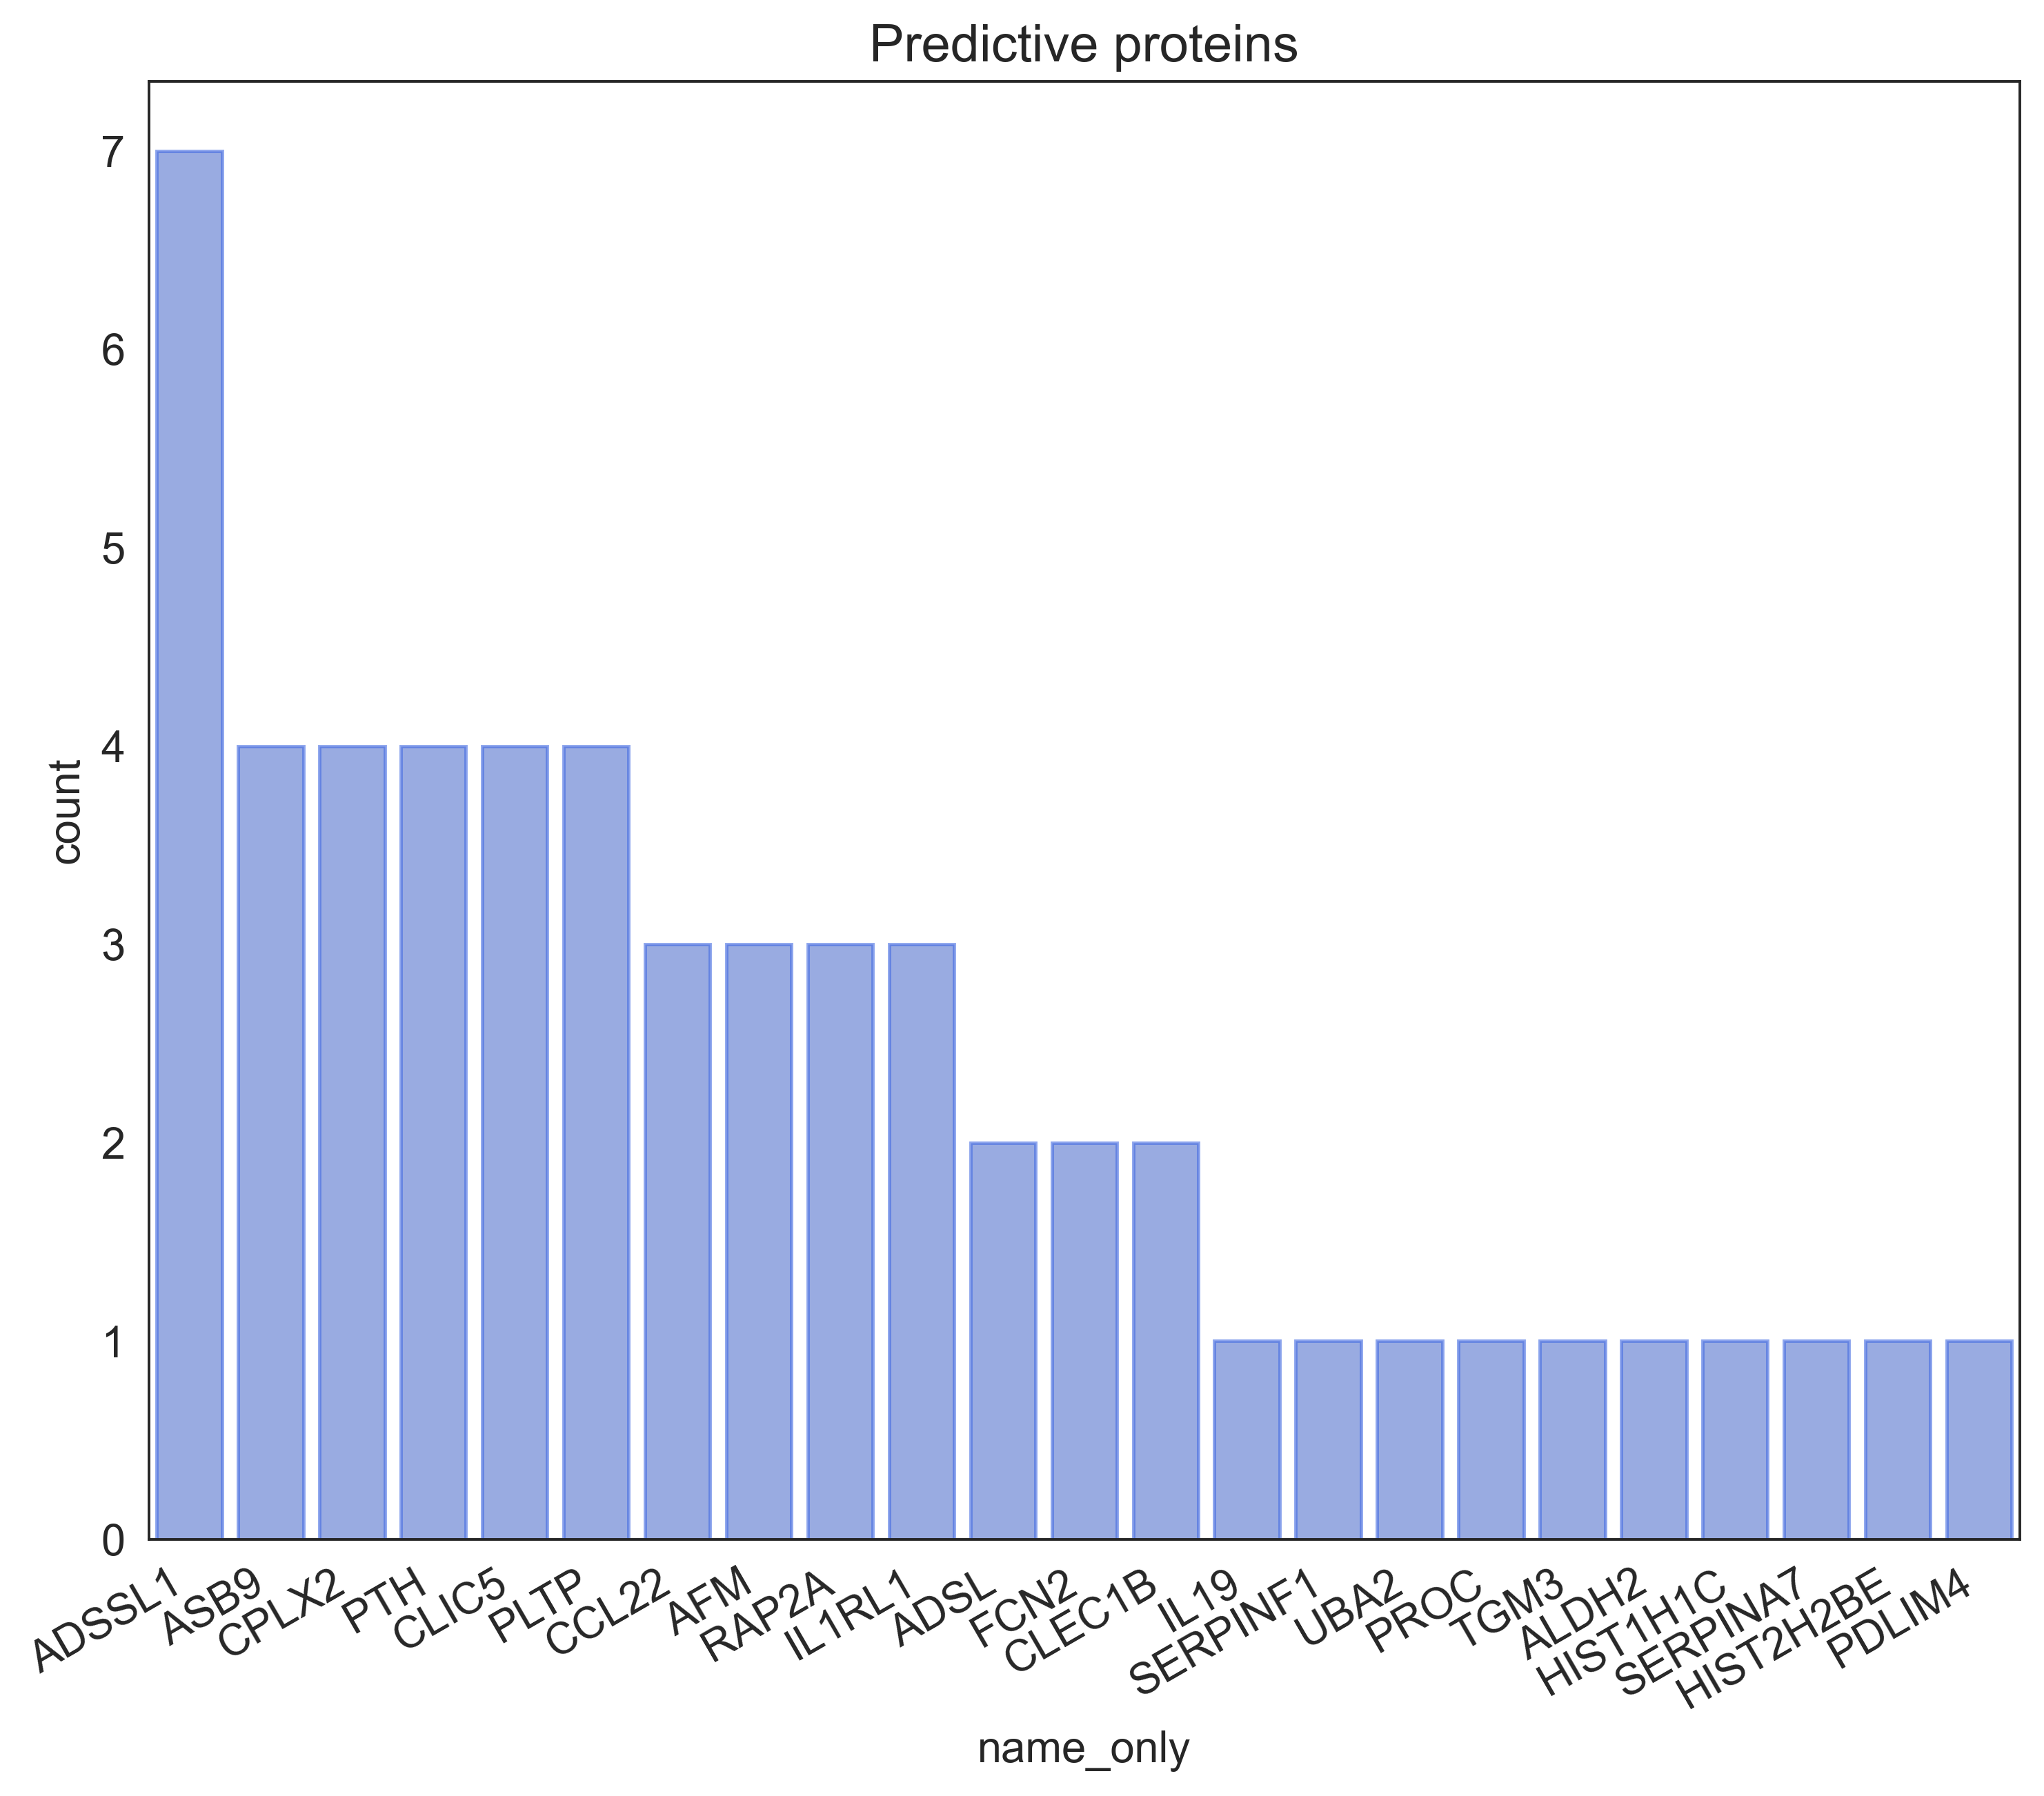

In [13]:
#select proteins that appeared > 0 (all)
flattened_list = np.concatenate(scores).ravel().tolist()
df_prot = pd.DataFrame(pd.Series(flattened_list).value_counts(), columns=['Frequency'])
most_frequent = df_prot[df_prot.iloc[:,0]>0].index
prot_full_list = pd.DataFrame(flattened_list, columns=['Prot_name'])

pos = []
for i, z in enumerate(prot_full_list.Prot_name):
    if z in most_frequent:
        pos.append(i)

# only the proteins that appeared 4 times or more
final_df_prot = prot_full_list.filter(items= pos, axis = 0)   
final_df_prot['name_only'] = [i.split(".")[0] for i in final_df_prot.Prot_name]

# plot proteins
font = {'family' : 'normal',
        'size'   : 13}
plt.rc('font', **font)
sns.set_style("white")
fig, ax = plt.subplots(figsize=(10,8), dpi=350)
fig = sns.countplot(final_df_prot['name_only'], 
                    order=final_df_prot.name_only.value_counts().index, 
                    color = "royalblue",
                    edgecolor ="royalblue", alpha = 0.6)
ax.set_title("Predictive proteins")

#plt.title("Predictive proteins")
plt.xticks(rotation=30, ha = 'right')
image_format='pdf'
image_name = '/Users/smasarone/Downloads/countplot_prot.pdf'
# plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')


# flattened_list = np.concatenate(scores).ravel().tolist()
# df_prot = pd.DataFrame(pd.Series(flattened_list).value_counts(), columns=['Frequency'])
# most_frequent = df_prot[df_prot.iloc[:,0]>0].index
# prot_full_list = pd.DataFrame(flattened_list, columns=['Prot_name'])

# pos = []
# for i, z in enumerate(prot_full_list.Prot_name):
#     if z in most_frequent:
#         pos.append(i)
# # only the proteins that appeared 4 times or more
# final_df_prot =  prot_full_list.filter(items= pos, axis = 0)   

# # plot proteins
# font = {'family' : 'normal',
#         'size'   : 13}
# plt.rc('font', **font)
# sns.set_style("whitegrid")
# fig, ax = plt.subplots(figsize=(10,6))
# fig = sns.countplot(final_df_prot.Prot_name, order=final_df_prot.Prot_name.value_counts().index, color = "royalblue")
# plt.title("Predictive proteins")
# plt.xticks(rotation=30, ha = 'right')
image_format='pdf'
image_name = '/Users/smasarone/Downloads/FiguresPaper/AppendixML/countplot_prot.pdf'

In [14]:
final_df_prot.Prot_name.unique()

array(['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7'], dtype=object)

### Model training using only these top 23 proteins

In [15]:
# create the target using only iss (no mortality) #25
y=[]
for i in clin.iss:
    if i>24:
        y.append(1)
    else:
        y.append(0)

#filter raw to only keep selected prot
prot_ = prot.filter(items = final_df_prot.Prot_name.unique(), axis = 1)

# preprocess the df
X_train, X_test, y_train, y_test = train_test_split(prot_, y, shuffle = True, test_size = 0.3, 
                                                    random_state = 32, stratify=y)        

#avoid data leakage
scaler = StandardScaler()
scaler.fit(X_train)
X_train_ = scaler.transform(X_train)
X_test_ = scaler.transform(X_test)

print(X_train_.shape)
print(X_test_.shape)
print(len(y_train))
print(len(y_test))

print("bincount:", np.bincount(y))

(289, 23)
(125, 23)
289
125
bincount: [306 108]


In [16]:
# training the model, we are using 24 rather than 33

dtrain = xgb.DMatrix(X_train_, label=y_train)
dtest = xgb.DMatrix(X_test_, label=y_test)
param = {'max_depth': 2, 'eta': 0.2, 'objective': 'binary:logistic', 'scale_pos_weight':3}
param['eval_metric'] = 'auc'
num_round = 20
evallist = [(dtest, 'eval'),(dtrain, 'train')] # eval test
progress = {}
bst_23 = xgb.train(param, dtrain, num_round, 
                     evallist, evals_result = progress, 
                     verbose_eval=10, 
                     early_stopping_rounds=25)


# classes in y_test
print(" ") 
print("bincount y_test:", np.bincount(y_test))

[0]	eval-auc:0.79068	train-auc:0.87389
[10]	eval-auc:0.87352	train-auc:0.96769
[19]	eval-auc:0.88076	train-auc:0.98455
 
bincount y_test: [92 33]


In [17]:
# check predictions
preds = bst_23.predict(dtest)
prediction =[]
for i in preds:
    if i >=0.5:
        prediction.append(1)
    else:
        prediction.append(0)
print(np.bincount(prediction))

# scores
precision_recall_fscore_support(y_test, prediction)

print(precision_score(y_test, prediction, average='weighted'))
print(recall_score(y_test, prediction, average='weighted'))
print(f1_score(y_test, prediction, average='weighted'))

[85 40]
0.8164705882352942
0.8
0.8056342388360033


In [18]:
##### EXTRA FOR DAN PASS TRAIN SET ######
preds_train = bst_23.predict(dtrain)

prediction_t =[]
for i in preds_train:
    if i >=0.5:
        prediction_t.append(1)
    else:
        prediction_t.append(0)
print(np.bincount(prediction_t))

# scores
precision_recall_fscore_support(y_train, prediction_t)
print(precision_score(y_train, prediction_t, average='weighted'))
print(recall_score(y_train, prediction_t, average='weighted'))
print(f1_score(y_train, prediction_t, average='weighted'))

[193  96]
0.9236109866073829
0.9065743944636678
0.9099008115580688


In [19]:
markers = ["d"]*125 + ["+"]*289

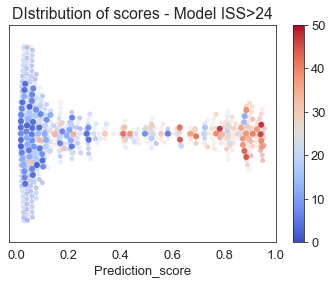

In [20]:
final_list = np.concatenate([preds, preds_train])

df_predictions = pd.DataFrame(final_list, index = X_test.index.append(X_train.index))
df_predictions['iss'] = clin.iss
df_predictions.columns =['Prediction_score', 'iss']
df_predictions['set'] = ['test']*125 +['train']*289



# colorbar
norm = plt.Normalize(df_predictions['iss'].min(), df_predictions['iss'].max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)

# we will plot these first as background on a lighter colour
# this is to show that they are training points
ax = sns.swarmplot(data=df_predictions, x='Prediction_score', 
                   y=['']*len(df_predictions), 
                   hue='iss',
                   palette='coolwarm',
                   alpha = 0.35)
plt.legend('',frameon=False)

ax.figure.colorbar(sm)
plt.title("DIstribution of scores - Model ISS>24")

test_only_v2 = df_predictions[df_predictions['set']=='test']
ax = sns.swarmplot(data=test_only_v2, x='Prediction_score',
                   y=['']*len(test_only_v2), hue='iss',
                   palette='coolwarm',
                  alpha = 0.9, s = 6)
plt.legend('',frameon=False)
image_name = '/Users/smasarone/Downloads/swarmplot_24.pdf'
plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


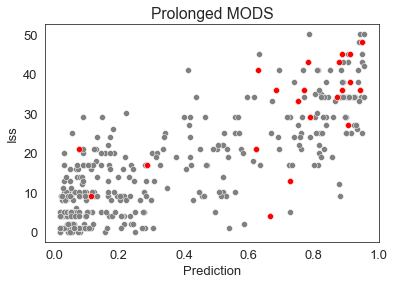

In [21]:
mods = pd.read_csv('New.MODS.groups(2022).csv', index_col=0, header=0)
idx_long = mods[mods['MODS.group']== 'Prolonged MODS'].index
long_ = df_predictions.filter(items =idx_long, axis = 0)

sns.scatterplot(df_predictions['Prediction_score'], df_predictions['iss'], color = 'grey')
sns.scatterplot(long_['Prediction_score'], long_['iss'], color = 'red')
plt.title("Prolonged MODS")
plt.ylabel("Iss")
plt.xlabel("Prediction")
plt.show()
image_name = '/Users/smasarone/Downloads/FiguresPaper/ISS_VS_PRED_24.pdf' 
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')


Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.


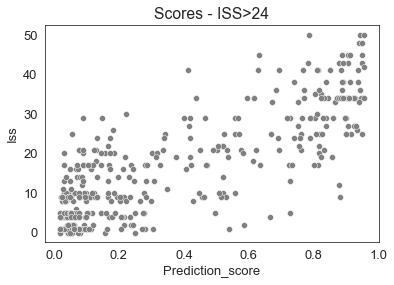

In [22]:
sns.scatterplot(df_predictions['Prediction_score'], df_predictions['iss'], color = 'grey')
plt.title("Scores - ISS>24")
plt.ylabel("Iss")

image_name = 'ISS_VS_PRED_24_GREY_ONLY.pdf' 
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

In [23]:
#np.concatenate([X_train_, X_test_])==train_test
bst_23.predict(dtrain).mean().round(2)

0.35

In [24]:
new_i=[]
for i in prot_.columns:
    new_i.append(i.split(".")[0])
    
current_index = list(X_train.index) + list(X_test.index)

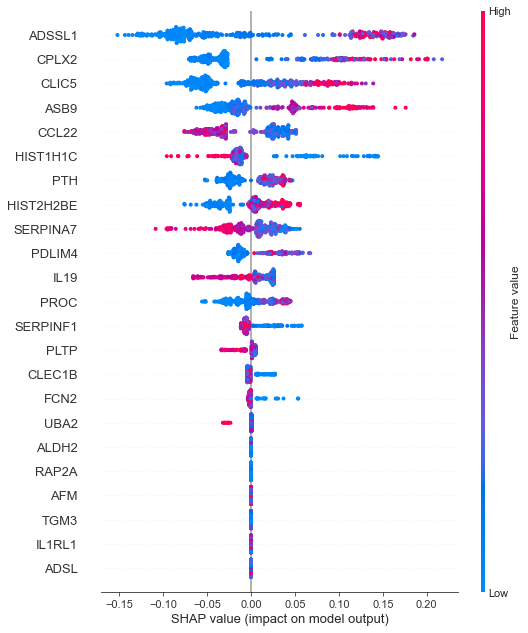

In [25]:
# Shap for the model built using a threshold of 25
import shap
shap.initjs

train_test_ = X_train.append(X_test)
train_test = scaler.transform(train_test_)
shap_values = shap.TreeExplainer(bst_23, X_train_, feature_perturbation = 'interventional', model_output='probability').shap_values(train_test)
fig = shap.summary_plot(shap_values, train_test, feature_names=new_i, show = False, max_display=23)
image_format = 'pdf'
image_name = '/Users/smasarone/Downloads/shap25.pdf'
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

Text(0, 0.5, 'Variance explained')

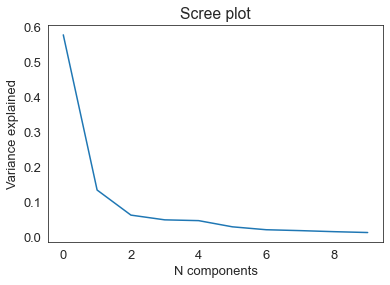

In [26]:
# pca of the 23 proteins
from sklearn.decomposition import PCA
train_test_index = X_train.index.append(X_test.index)
pca = PCA(n_components = 10)
pca_shap = pca.fit_transform(shap_values)

plt.title("Scree plot")
sns.lineplot(x = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], y = pca.explained_variance_ratio_)
plt.xlabel("N components")
plt.ylabel("Variance explained")


In [27]:
shap_24_df = pd.DataFrame(shap_values, index = train_test_index)
shap_24_df.columns = new_i
#shap_24_df.to_csv('/Users/smasarone/Downloads/jupyter_notebooks_copy2/shap_values_24.csv')


In [28]:
pca.explained_variance_ratio_


array([0.57743635, 0.1345876 , 0.06301273, 0.04950849, 0.04729027,
       0.02960032, 0.02129568, 0.01877559, 0.01577621, 0.01332268])

In [29]:
a = ['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7']
df__ = pd.DataFrame(pca.components_[0:3,:]).T
df__.index = a
df__.iloc[:,1].sort_values(ascending = False)


CPLX2.15321.8        8.654610e-01
ASB9.19601.15        1.437919e-01
PROC.3758.68         5.615430e-02
PDLIM4.12387.7       2.094133e-02
PTH.5954.62          1.555398e-02
HIST2H2BE.14143.8    1.434567e-02
SERPINF1.9211.19     1.114859e-02
PLTP.15475.4         8.990804e-03
FCN2.13717.15        3.473643e-04
ADSL.5023.23         3.308722e-24
AFM.4763.31          0.000000e+00
RAP2A.9885.41        0.000000e+00
TGM3.4471.50         0.000000e+00
IL1RL1.4234.8        0.000000e+00
ALDH2.18381.16       0.000000e+00
CLEC1B.4332.6       -2.065821e-03
UBA2.12500.88       -5.190542e-03
SERPINA7.2706.69    -1.066606e-02
IL19.3035.80        -1.803599e-02
CCL22.3508.78       -6.682349e-02
HIST1H1C.2987.37    -8.475229e-02
CLIC5.12475.48      -1.632309e-01
ADSSL1.13998.26     -4.327742e-01
Name: 1, dtype: float64

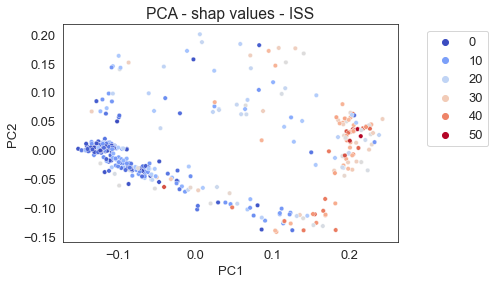

In [31]:
clin_reidx = clin.reindex(train_test_index)
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = clin_reidx['iss'], 
                palette = 'coolwarm', s = 20)
plt.title("PCA - shap values - ISS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))

In [32]:
# cell o save the data and work on plot separately
df_to_export_24 = pd.DataFrame(pca_shap)
df_to_export_24.index = train_test_index
#df_to_export_24.to_csv('/Users/smasarone/Documents/jupyter_notebooks_copy2/PCA_24.csv')

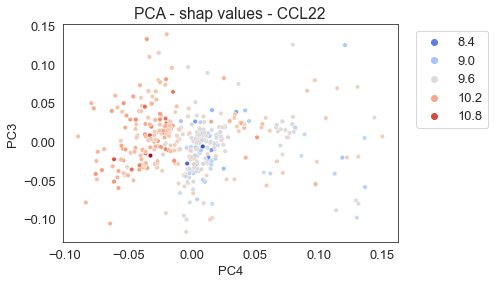

In [33]:
prot_r = prot.reindex(train_test_index)
sns.scatterplot(x = pca_shap[:, 2], y = pca_shap[:,3], 
                hue = np.log(prot_r.loc[:,'CCL22.3508.78']), 
                palette = 'coolwarm', s = 20)
plt.title("PCA - shap values - CCL22")
plt.xlabel("PC4")
plt.ylabel("PC3")
plt.legend(bbox_to_anchor=(1.29, 1.0)) 

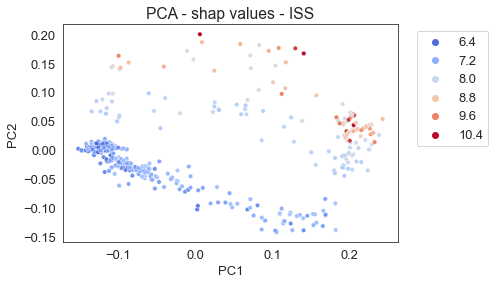

In [46]:
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = np.log(prot_r.loc[:,'CPLX2.15321.8']), 
                palette = 'coolwarm', s = 20)
plt.title("PCA - shap values - ISS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))
image_name = '/Users/smasarone/Downloads/FiguresPaper/SHAP_24_CPLX2.pdf'
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

In [1]:
### INSPECT FORCE PLOTS

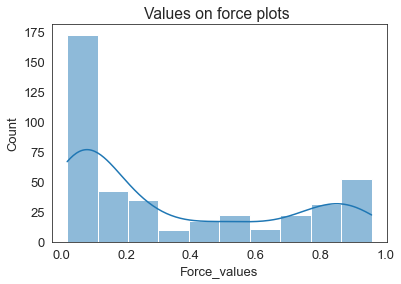

Force_values    0.815248
dtype: float64


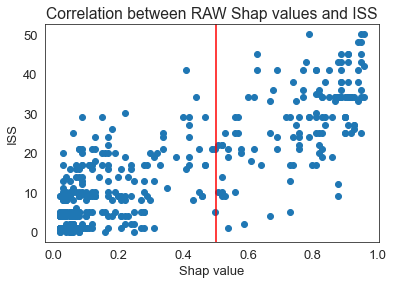

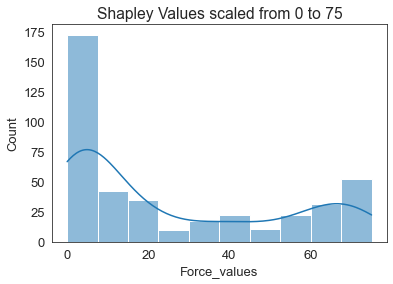

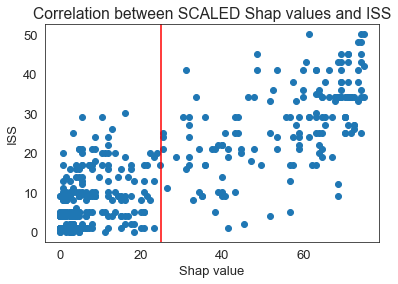

In [47]:
### Inspect force plots model at 24
explainer = shap.TreeExplainer(bst_23, X_train_, feature_perturbation = 'interventional', model_output='probability')
base_value = explainer.expected_value

force_values=[]
for i in range(len(shap_values)):
    force_values.append(base_value+shap_values[i,:].sum().round(2))

# force df
df_force = pd.DataFrame(force_values, index=current_index)
df_force.columns=['Force_values']

plt.title("Values on force plots ")
sns.histplot(df_force.Force_values, kde = True)
plt.show()

# getting the top critical and bottom ones
non_critical_50 = df_force.sort_values('Force_values')[0:50].index
critical_50 = df_force.sort_values('Force_values', ascending = False)[0:50].index

clin_crit_50 = clin.filter(items = critical_50, axis = 0)
clin_non_crit_50 = clin.filter(items = non_critical_50, axis = 0)

# correlation between ISS and force
print(df_force.corrwith(clin['iss']))

plt.title("Correlation between RAW Shap values and ISS")
plt.scatter(df_force['Force_values'], clin['iss'].reindex(df_force.index))
plt.axvline(x = 0.5, c = 'red')
plt.xlabel('Shap value')
plt.ylabel("ISS")
plt.show()

#### Scale 
# make a score that goes from 0 to 75
def ScaleinRange(data):
    return (data - np.min(data))/(np.max(data) - np.min(data))*(75-0)

scaled0_75 = ScaleinRange(df_force['Force_values'])
sns.histplot(scaled0_75, kde=True)
plt.title("Shapley Values scaled from 0 to 75")
plt.show()

# plot correlation between the values scaled and ISS
plt.title("Correlation between SCALED Shap values and ISS")
plt.scatter(scaled0_75, clin['iss'].reindex(df_force.index))
plt.axvline(x = 25, c = 'red')
plt.xlabel('Shap value')
plt.ylabel("ISS")
plt.show()

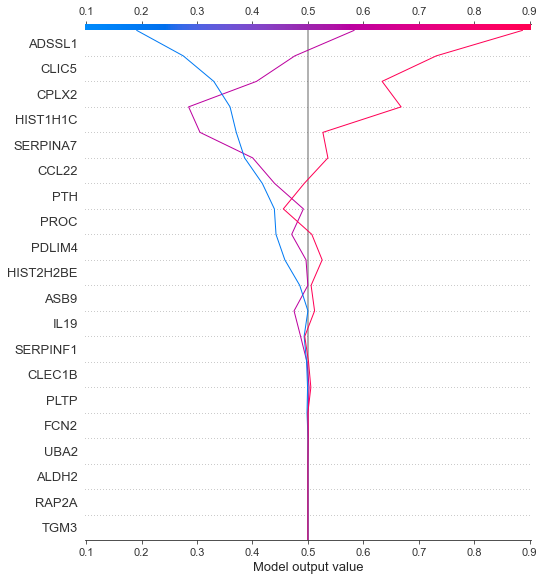

In [48]:
## decision plots
selected = [5, 92, 195] 
selected2 = [81, 3, 195, 1]
fig = shap.decision_plot(0.5, shap_values[selected], feature_names=new_i, show=False)
image_name = '/Users/smasarone/Downloads/FiguresPaper/Decision_plot_24_V3.pdf'
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

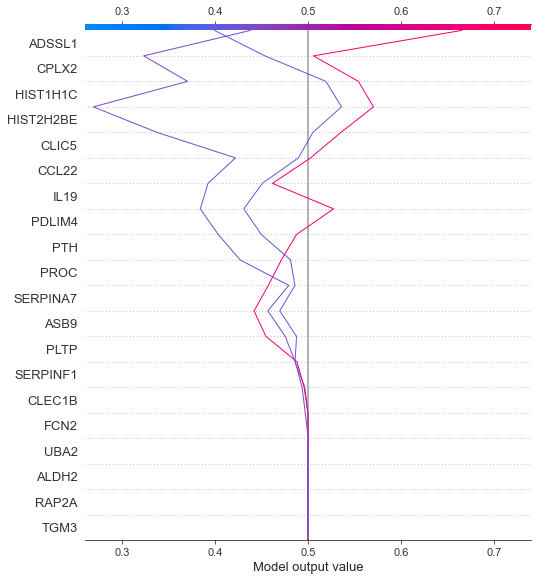

In [49]:
selected = [13, 192, 19] 
fig = shap.decision_plot(0.5, shap_values[selected], feature_names=new_i, show=False)


In [50]:
# get only force values for the test set
test_only = df_force.filter(items = X_test.index, axis=0)

In [51]:
# make a df with corrected labels ("results modelling")
res_mod = pd.DataFrame(y_test, columns = ['real_label'])
res_mod['predictions'] = prediction
res_mod.index=X_test.index
res_mod['shap_values'] = test_only['Force_values']

#check which patients were non critical but predicted as critical
count=0
model_mis=[]
for i in res_mod.index:
    if res_mod.loc[i, 'real_label']==0 and res_mod.loc[i, 'predictions']==1:
        count+=1
        model_mis.append(i)
        #print(i, res_mod.loc[i, 'shap_values'])
print("Misclassified as critical by the model:", count)

print(" ")        
shap_misclass=[]
count=0
for i in res_mod.index:
    if res_mod.loc[i, 'real_label']==0 and res_mod.loc[i, 'shap_values']>= 0.5: # we changed it bhere because we are usinng probabilities here
        #print(i, res_mod.loc[i, 'shap_values'])
        shap_misclass.append(i)
        count+=1
print("Misclassified as critical by SHAP:", count) 

#res_mod.filter(items = shap_misclass, axis=0)

Misclassified as critical by the model: 16
 
Misclassified as critical by SHAP: 15


In [52]:
res_mod[res_mod['real_label']==1]

,real_label,predictions,shap_values
TubeUniqueID,,,
311,1,1,0.948312
241,1,1,0.788312
362,1,1,0.528312
970,1,0,0.408312
103,1,1,0.668312
1059,1,1,0.788312
1512,1,1,0.928312
767,1,0,0.438312
1337,1,1,0.628312


In [53]:
#misclassified at iss >24
pd.set_option('display.max_columns', None)
clin.filter(items=model_mis, axis =0).head(25)
clin.filter(items = [1131,1573, 319, 1442], axis = 0)

,sex,age,injury_date,injury_time,injury_date_time,injury_code,injury_type,iss,admission_time,admission_hr,admission_sbp,admission_gcs,injury_to_baseline_sample_time,baseline_hb,baseline_hct,baseline_wcc,baseline_plt,baseline_lactate,baseline_base_deficit,24hr_crystalloid_volume,24hr_colloid_volume_ml,24hr_prbc_volume,24hr_ffp_volume,24hr_plts_volume,24hr_cryoprecipitate_volume,24hr_octaplas_volume,24hr_hypertonic_saline_volume,itu_days,hdu_days,ventilator_days,ventilator_free_days,length_of_stay,28_day_mortality,injury_to_death,vent_free_calculated,percent_vent_free,total_txa,inf
record_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1131,Male,21,02/06/2014 00:00,0.768750,02/06/2014 18:27,10. Jump from height,Blunt,12,19:44:00,86.0,113.0,14.0,82.0,16.2,0.44,17.2,243.0,1.4,0.8,7100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,28.0,30,1,NaN,30.0,100.00,0,no
1573,Male,68,16/11/2016 00:00,0.555556,16/11/2016 13:20,1. Pedestrian vs vehicle,Blunt,21,14:19:00,107.0,195.0,3.0,68.0,13.9,0.41,19.0,205.0,2.2,2.5,4426.0,0.0,0.0,0.0,0.0,0.0,0.0,200.0,11,2.0,5.0,17.0,55,1,NaN,50.0,90.91,2,yes
319,Female,23,05/09/2009 00:00,0.367361,05/09/2009 08:49,10. Jump from height,Blunt,17,10:07:00,85.0,115.0,15.0,82.0,12.6,0.38,16.4,280.0,2.8,3.4,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,28.0,33,1,NaN,33.0,100.00,0,no
1442,Male,23,12/02/2016 00:00,0.549306,12/02/2016 13:11,8. Fall from height,Blunt,9,15:10:00,72.0,130.0,15.0,124.0,14.4,0.41,9.8,196.0,1.9,-2.6,2000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,NaN,4,1,NaN,4.0,100.00,0,yes


In [54]:
#V2
#check which patients were critical but predicted as not critical
count2=0
model_mis2=[]
for i in res_mod.index:
    if res_mod.loc[i, 'real_label']==1 and res_mod.loc[i, 'predictions']==0:
        count2+=1
        model_mis2.append(i)
print("Misclassified as critical by the model:", count2)

print(" ")        
shap_misclass2=[]
count2=0
for i in res_mod.index:
    if res_mod.loc[i, 'real_label']==1 and res_mod.loc[i, 'shap_values']<= 0.5: # we changed it bhere because we are usinng probabilities here
        #print(i, res_mod.loc[i, 'shap_values'])
        shap_misclass2.append(i)
        count2+=1
print("Misclassified as non critical by SHAP:", count2) 

clin.filter(items=model_mis2, axis =0).head(15)

Misclassified as critical by the model: 9
 
Misclassified as non critical by SHAP: 9


,sex,age,injury_date,injury_time,injury_date_time,injury_code,injury_type,iss,admission_time,admission_hr,admission_sbp,admission_gcs,injury_to_baseline_sample_time,baseline_hb,baseline_hct,baseline_wcc,baseline_plt,baseline_lactate,baseline_base_deficit,24hr_crystalloid_volume,24hr_colloid_volume_ml,24hr_prbc_volume,24hr_ffp_volume,24hr_plts_volume,24hr_cryoprecipitate_volume,24hr_octaplas_volume,24hr_hypertonic_saline_volume,itu_days,hdu_days,ventilator_days,ventilator_free_days,length_of_stay,28_day_mortality,injury_to_death,vent_free_calculated,percent_vent_free,total_txa,inf
record_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
970,Male,52,03/07/2013 00:00,0.472917,03/07/2013 11:21,8. Fall from height,Blunt,41,12:29:00,80.0,143.0,15.0,68.0,12.7,0.36,11.1,310.0,0.9,-1.5,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,28.0,21,1,NaN,21.0,100.00,0,no
767,Male,82,14/10/2012 00:00,0.519444,14/10/2012 12:28,1. Pedestrian vs vehicle,Blunt,34,13:30:00,92.0,106.0,13.0,72.0,14.7,0.44,12.4,221.0,5.5,-2.0,2400.0,750.0,0.0,0.0,0.0,0.0,0.0,0.0,0,8.0,0.0,28.0,12,1,NaN,12.0,100.00,0,no
1379,Male,28,23/07/2015 00:00,0.353472,23/07/2015 08:29,1. Pedestrian vs vehicle,Blunt,26,09:16:00,58.0,100.0,15.0,47.0,13.2,0.38,9.3,184.0,1.9,-0.2,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,11.0,0.0,28.0,32,1,NaN,32.0,100.00,1,yes
128,Male,19,22/12/2008 00:00,0.604167,22/12/2008 14:30,4. Car vs vehicle,Blunt,27,16:11:00,140.0,152.0,8.0,108.0,15.3,0.43,33.2,127.0,2.3,0.5,3000.0,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,28.0,25,1,NaN,25.0,100.00,0,no
509,Female,45,15/02/2011 00:00,0.381250,15/02/2011 09:09,1. Pedestrian vs vehicle,Blunt,25,11:02:00,116.0,170.0,6.0,116.0,10.5,0.33,11.0,350.0,1.0,2.2,2000.0,500.0,1.0,0.0,0.0,0.0,0.0,0.0,8,0.0,1.0,20.0,30,1,NaN,29.0,96.67,0,no
586,Male,23,03/08/2011 00:00,0.588889,03/08/2011 14:08,14. Cyclist vs vehicle,Blunt,29,15:30:00,144.0,119.0,13.0,82.0,15.0,0.45,11.1,296.0,0.9,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,28.0,3,1,NaN,3.0,100.00,0,no
274,Male,57,24/06/2009 00:00,0.440972,24/06/2009 10:35,8. Fall from height,Blunt,30,12:09:00,122.0,146.0,3.0,100.0,12.5,0.37,20.1,215.0,1.3,2.6,4580.0,4000.0,0.0,0.0,0.0,0.0,0.0,0.0,7,0.0,5.0,NaN,7,1,NaN,2.0,28.57,0,no
1253,Female,72,20/01/2015 00:00,0.490972,20/01/2015 11:47,6. Pedestrian vs falling object,Blunt,29,12:47:00,108.0,145.0,12.0,67.0,13.6,0.39,11.4,228.0,1.5,-1.1,2500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,4.0,0.0,28.0,28,1,NaN,28.0,100.00,2,yes
453,Male,35,20/08/2010 00:00,0.693056,20/08/2010 16:38,6. Pedestrian vs falling object,Blunt,25,18:27:00,116.0,135.0,14.0,115.0,14.1,0.41,18.2,154.0,1.6,5.8,1437.0,3000.0,3.0,0.0,0.0,0.0,0.0,0.0,3,0.0,0.0,28.0,147,1,NaN,147.0,100.00,0,no


In [55]:
pca_df = pd.DataFrame(pca_shap, index=clin_reidx.index)
misclass = pca_df.filter(items = model_mis, axis = 0)

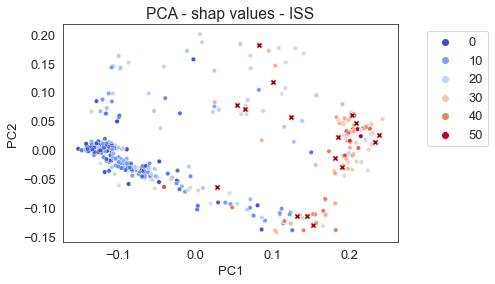

In [56]:
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = clin_reidx['iss'], 
                palette = 'coolwarm', s = 20)
sns.scatterplot(x = misclass.iloc[:, 0], y = misclass.iloc[:,1], color = 'darkred', 
                marker ="X")

plt.title("PCA - shap values - ISS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))
image_format = 'pdf'
image_name = "/Users/smasarone/Downloads/miscalssified.pdf"
plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

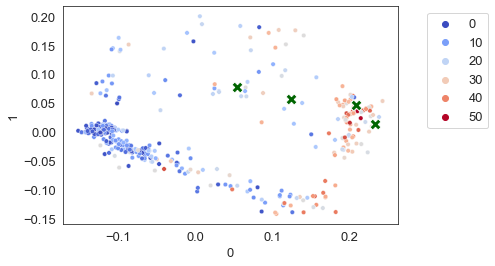

In [65]:
examples = misclass.filter(items = [1131,1573, 319, 1442], axis = 0)
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = clin_reidx['iss'], 
                palette = 'coolwarm', s = 20)
sns.scatterplot(x = examples.iloc[:, 0], y = examples.iloc[:,1], 
                color = 'darkgreen', 
                marker ="X", 
                s = 120)
plt.legend(bbox_to_anchor=(1.29, 1.0))

In [ ]:
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = clin_reidx['iss'], 
                palette = 'coolwarm', s = 20)
sns.scatterplot(x = examples.iloc[:, 0], y = examples.iloc[:,1], 
                color = 'darkgreen', 
                marker ="X", 
                s = 120)
plt.legend(bbox_to_anchor=(1.29, 1.0))



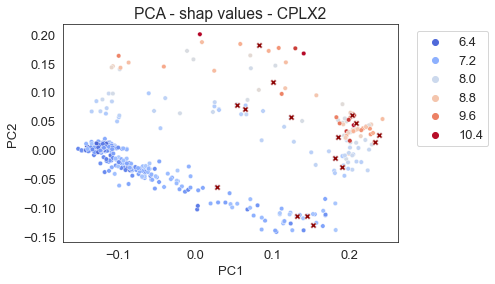

In [65]:
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = np.log(prot_r.loc[:,'CPLX2.15321.8']), 
                palette = 'coolwarm', s = 20)

sns.scatterplot(x = misclass.iloc[:, 0], y = misclass.iloc[:,1], color = 'darkred', 
                marker ="X")

plt.title("PCA - shap values - CPLX2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))

image_name = "/Users/smasarone/Downloads/miscalssified_CPLX2.pdf"
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

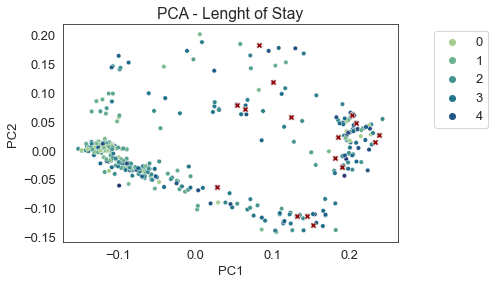

In [66]:
sns.scatterplot(x = pca_shap[:, 0], y = pca_shap[:,1], 
                hue = np.log(clin_reidx['length_of_stay']+1), 
                palette = 'crest', s = 20)
sns.scatterplot(x = misclass.iloc[:, 0], y = misclass.iloc[:,1], color = 'darkred', 
                marker ="X")

plt.title("PCA - Lenght of Stay")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))
image_name = "/Users/smasarone/Downloads/miscalssified_los.pdf"
plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

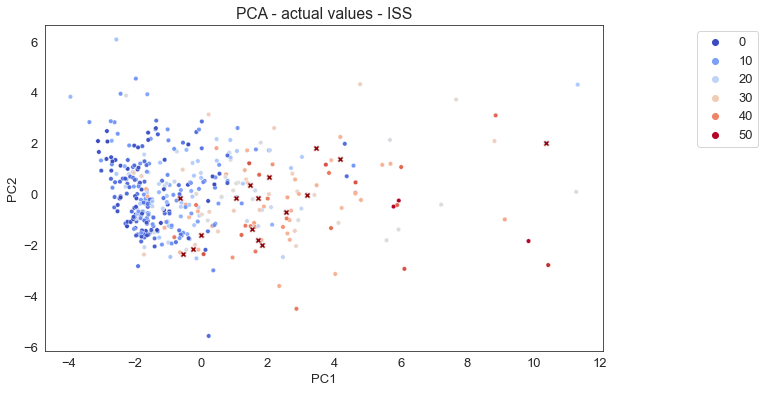

In [67]:
prot_23 = df_scaled.filter(items=a, axis=1)
pca = PCA()
res_orig = pca.fit_transform(prot_23)
pca_or_df = pd.DataFrame(res_orig, index = prot_23.index)
real_pca_mis = pca_or_df.filter(items = misclass.index, axis=0)

plt.figure(figsize = (10, 6))
sns.scatterplot(x = res_orig[:, 0], y = res_orig[:,1], 
                hue = clin['iss'], 
                palette = 'coolwarm', s = 20)

sns.scatterplot(x = real_pca_mis.iloc[:, 0], y = real_pca_mis.iloc[:,1], color = 'darkred', 
                marker ="X")

plt.title("PCA - actual values - ISS")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.29, 1.0))

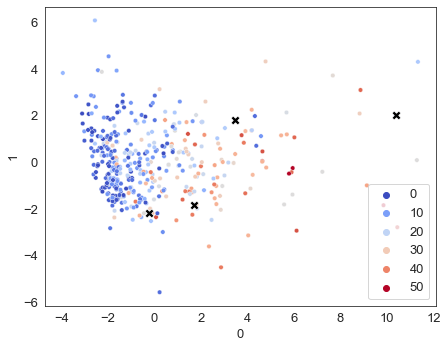

In [73]:
plt.figure(figsize = (7, 5.5))
real_examples = pca_or_df.filter(items =[1131, 1573, 319, 1442], axis=0)
sns.scatterplot(x = res_orig[:, 0], y = res_orig[:,1], 
                hue = clin['iss'], 
                palette = 'coolwarm', s = 20)
sns.scatterplot(x = real_examples.iloc[:, 0], y = real_examples.iloc[:,1], 
                color = 'black', s = 80, marker = 'X')
image_name = "/Users/smasarone/Downloads/miscalssified_pca.pdf"
plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

In [69]:
shap.initjs()
for i, z in enumerate(train_test_.index):
    if z == 1459:
        print(i)
        
# 328 is the mismatch
df_1 = pd.DataFrame(train_test, index= train_test_.index, columns = train_test_.columns)
shap.force_plot(0.5, shap_values[151,:], df_1.iloc[151,:], plot_cmap="PkYg", show = False)
#image_name = '/Users/smasarone/Downloads/FiguresPaper/Shap_critical_24_1.pdf'
#plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

328


In [70]:
### CCL22 pushed towards non critical
shap.force_plot(0.5, shap_values[81,:], df_1.iloc[81,:], plot_cmap="PkYg")

In [71]:
#### Additional force plots
shap.force_plot(0.5, shap_values[40,:], df_1.iloc[40,:], plot_cmap="PkYg")

In [72]:
shap.force_plot(0.5, shap_values[12,:], df_1.iloc[12,:], plot_cmap="PkYg")

In [73]:
shap.force_plot(0.5, shap_values[34,:], df_1.iloc[34,:], plot_cmap="PkYg")

In [74]:
shap.force_plot(0.5, shap_values[133,:], df_1.iloc[133,:], plot_cmap="PkYg")

In [75]:
shap.force_plot(0.5, shap_values[412,:], df_1.iloc[412,:], plot_cmap="PkYg")

In [76]:
shap.force_plot(0.5, shap_values[405,:], df_1.iloc[405,:], plot_cmap="PkYg")

### Contributions for the model at ISS >24

In [77]:
### Check the contributions of the force plots

prot_list_ = ['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7']

sign=[]
largest_contrib=[]
for i in range(0, len(prot)):
    name = prot_list_[np.argmax(np.abs(shap_values[i,:]))]
    position = np.argmax(np.abs(shap_values[i,:]))
    largest_contrib.append(name)
    if shap_values[i, position]> 0:
        sign.append('positive')
    else:
        sign.append('negative')
    
np.unique(largest_contrib)

array(['ADSSL1.13998.26', 'ASB9.19601.15', 'CCL22.3508.78',
       'CLIC5.12475.48', 'CPLX2.15321.8', 'HIST1H1C.2987.37',
       'SERPINF1.9211.19'], dtype='<U16')

In [78]:
contrib_idx = X_train.index.append(X_test.index)
contrib_df = pd.DataFrame(largest_contrib, columns=['Largest_contrib'])
contrib_df['sign'] = sign
contrib_df.index = contrib_idx
contrib_df['Largest_contrib'].unique()
contrib_df[contrib_df['Largest_contrib']=='ASB9.19601.15']

,Largest_contrib,sign
TubeUniqueID,,
234,ASB9.19601.15,positive
1361,ASB9.19601.15,positive
280,ASB9.19601.15,positive
1768,ASB9.19601.15,positive
1372,ASB9.19601.15,positive
1635,ASB9.19601.15,positive
1159,ASB9.19601.15,positive
340,ASB9.19601.15,positive
426,ASB9.19601.15,positive


In [79]:
for i, z in enumerate(X_train.index.append(X_test.index)):
    if z == 215:
        print(i)

405


In [80]:
contrib_df['Largest_contrib']

TubeUniqueID
950      ADSSL1.13998.26
1209       CPLX2.15321.8
561      ADSSL1.13998.26
254      ADSSL1.13998.26
928      ADSSL1.13998.26
              ...       
174      ADSSL1.13998.26
1108      CLIC5.12475.48
1442     ADSSL1.13998.26
45      SERPINF1.9211.19
747      ADSSL1.13998.26
Name: Largest_contrib, Length: 414, dtype: object

#### Resume analysis

In [81]:
iss = clin['iss']
iss_palette = sns.color_palette("coolwarm", 50)
dict_row = dict(zip(iss.unique(), iss_palette))
mapping_sev = iss.map(dict_row)

#mapping_sev.values
#shap.force_plot(0.5, shap_values, train_test_, plot_cmap = 'New')

In [82]:
from matplotlib.colors import ListedColormap

iss= clin['iss']
iss_palette = sns.color_palette("coolwarm", 50)
dict_row = dict(zip(iss, iss_palette))
mapping_sev = iss.map(dict_row)

newcmp = ListedColormap(mapping_sev, name='New')

In [83]:
## we will run a CV model to see if that's consistent
## we will append y_train to y_test because they have been shuffled so we can't directly use y

df_scaled = scaler.transform(X_train.append(X_test))
y_ = np.append(y_train, y_test)

param = {'max_depth': 2, 'eta': 0.2, 'objective': 'binary:logistic', 'scale_pos_weight':3}
param['eval_metric'] = 'auc' 
fulldf = xgb.DMatrix(df_scaled, label=y_)
res = xgb.cv(dtrain=fulldf, 
             params = param, 
             num_boost_round=20, 
             nfold=5, 
             metrics = 'auc', 
             early_stopping_rounds=5, 
             seed=123451)

print("CV test mean AUC:", res['test-auc-mean'].iloc[-1])

CV test mean AUC: 0.8835388


In [84]:
y_= y_train+y_test
print(len(y_))

model= xgb.XGBClassifier(**param, use_label_encoder=False)
kfold = StratifiedKFold(n_splits=3)

# auc
results = cross_val_score(model, df_scaled, y_ , cv=kfold, scoring='roc_auc')
print("Auc: %.2f%% (%.2f%%)" % (results.mean()*100, results.std()*100))

#recall
results2 = cross_val_score(model, df_scaled, y_, cv=kfold, scoring='recall_weighted')
print("Recall: %.2f%% (%.2f%%)" % (results2.mean()*100, results2.std()*100))

414
Auc: 87.70% (2.91%)
Recall: 81.40% (1.90%)


Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or :meth:`sklearn.metric.RocCurveDisplay.from_estimator`.
Function plot_roc_curve is deprecated; Function :func:`plot_roc_curve` is deprecated in 1.0 and will be removed in 1.2. Use one of the class methods: :meth:`sklearn.metric.RocCurveDisplay.from_predictions` or

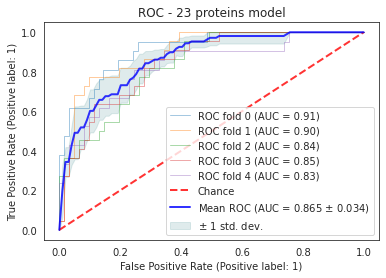

In [85]:
from sklearn import metrics
cv = StratifiedKFold(n_splits=5)

param = {'max_depth': 2, 'eta': 0.2, 'objective': 'binary:logistic', 'scale_pos_weight':3}
model= xgb.XGBClassifier(**param, eval_metric = 'auc',use_label_encoder=False)
y_array = np.array(y_)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100) #straight line for dumb classifier


font = {'family' : 'normal',
        'size'   : 10}
plt.rc('font', **font)
fig, ax = plt.subplots()
for i, (train, test) in enumerate(cv.split(df_scaled,y_array)):
    model.fit(df_scaled[train], y_array[train])
    viz = plot_roc_curve(model, df_scaled[test], y_array[test],
                         name='ROC fold {}'.format(i),
                         alpha=0.4, lw=1, ax=ax)
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
        label='Chance', alpha=.8)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(mean_fpr, mean_tpr, color='b',
        label=r'Mean ROC (AUC = %0.3f $\pm$ %0.3f)' % (mean_auc, std_auc),
        lw=2, alpha=.8)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='cadetblue', alpha=.2,
                label=r'$\pm$ 1 std. dev.')

ax.set(xlim=[-0.05, 1.05], ylim=[-0.05, 1.05],
       title="ROC - 23 proteins model")
ax.legend(loc="lower right")

plt.legend()
image_name = "/Users/smasarone/Downloads/roc_curve_23.pdf"
plt.savefig(image_name, format=image_format, dpi=1200, bbox_inches='tight')

In [124]:
new_idx = ['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7']


### Re-run model to explore predictions and get table

In [152]:
# preprocess the df
y=[]
for i in clin.iss:
    if i>24:
        y.append(1)
    else:
        y.append(0)

#filter to only keep sel prot
prot_ = prot.filter(items = final_df_prot.Prot_name.unique(), axis = 1)

# preprocess the df
X_train, X_test, y_train, y_test = train_test_split(prot_, y, shuffle = True, test_size = 0.3, 
                                                    random_state = 32, stratify=y)        

#avoid data leakage
scaler = StandardScaler()
scaler.fit(X_train)
X_train_ = scaler.transform(X_train)
X_test_ = scaler.transform(X_test)

print("bincount:", np.bincount(y))
dtrain = xgb.DMatrix(X_train_, label=y_train)
dtest = xgb.DMatrix(X_test_, label=y_test)
param = {'max_depth': 2, 'eta': 0.2, 'objective': 'binary:logistic', 'scale_pos_weight':3}
param['eval_metric'] = 'auc'
num_round = 20
evallist = [(dtest, 'eval'),(dtrain, 'train')] # eval test
progress = {}
bst_23 = xgb.train(param, dtrain, num_round, 
                     evallist, evals_result = progress, 
                     verbose_eval=10, 
                     early_stopping_rounds=25)


# classes in y_test
print(" ")
print("bincount y_test:", np.bincount(y_test))

bincount: [306 108]
[0]	eval-auc:0.79068	train-auc:0.87389
[10]	eval-auc:0.87352	train-auc:0.96769
[19]	eval-auc:0.88076	train-auc:0.98455
 
bincount y_test: [92 33]


In [153]:
# generate the table to compare critical defined by the model and critical defined by ISS >25
new_los = pd.read_csv('clinical_data_JR_20211110.csv', index_col = 0)
clin['NEW_LOS'] = new_los['length_of_stay_new']

preds = bst_23.predict(dtest)
classes = [1 if i >=0.5 else 0 for i in preds]
df_.index = X_train.index.append(X_test.index)
df_class = pd.DataFrame(classes)

#predicted label(by model)
crit_index=[]
non_crit_index=[]
for i in range(len(df_class)):
    if df_class.iloc[i,0]==1:
        crit_index.append(X_test.index[i]) #df_13p
    else:
        non_crit_index.append(X_test.index[i]) 

In [154]:
# real labels
clin_test = clin.filter(items = X_test.index, axis = 0)

real_crit=[]
real_non_crit=[]
        
for i in (clin.index):
    if i in X_test.index:
        if clin.loc[i,'iss'] > 24:
            real_crit.append(i)
        else:
            real_non_crit.append(i)
    else:
        continue
        
#quick test
assert len(real_non_crit) + len(real_crit) == len(X_test) 


# pred labels 
clin_crit_p = clin.filter(items=crit_index, axis=0)
clin_non_crit_p = clin.filter(items=non_crit_index, axis=0)

# real label
clin_crit_r = clin.filter(items=real_crit, axis=0)
clin_non_crit_r = clin.filter(items=real_non_crit, axis=0)

print("pred:", clin_crit_p.shape)
print("non crit pred: ", clin_non_crit_p.shape)
print("real",clin_crit_r.shape)
print("non crit real: ", clin_non_crit_r.shape)

#check we have 125 elements in both
assert len(clin_crit_p) + len(clin_non_crit_p) == len(clin_crit_r)+len(clin_non_crit_r)

pred: (40, 39)
non crit pred:  (85, 39)
real (33, 39)
non crit real:  (92, 39)


In [155]:
#some patients are different between the two critical groups
print("pred crit but not labelled as such:", len(set(clin_crit_p.index) - set(clin_crit_r.index)))
print("crit that were not predicted:", len(set(clin_crit_r.index)- set(clin_crit_p.index)))

print("intersection:", len(set(clin_crit_p.index) & set(clin_crit_r.index)))

pred crit but not labelled as such: 16
crit that were not predicted: 9
intersection: 24


In [156]:
# read the new los 
clin_descr_r = clin_crit_r.mean().round(1)
clin_descr_p = clin_crit_p.mean().round(1)
clin_descr_r_std = clin_crit_r.std().round(1)
clin_descr_p_std = clin_crit_p.std().round(1)

clin_descr_r = pd.DataFrame(clin_descr_r)
clin_descr_r.columns = ['median']
clin_descr_r['std'] = clin_descr_r_std
clin_descr_r = clin_descr_r.T

clin_descr_p = pd.DataFrame(clin_descr_p)
clin_descr_p.columns = ['median']
clin_descr_p['std'] = clin_descr_p_std
clin_descr_p = clin_descr_p.T

#drop useless columns
clin_descr_p = clin_descr_p.drop(columns=['injury_time', 'iss',
       'admission_gcs', 'baseline_hb',
       'baseline_hct', 'baseline_plt',
       '24hr_crystalloid_volume',
       '24hr_colloid_volume_ml', '24hr_prbc_volume', '24hr_ffp_volume',
       '24hr_plts_volume', 'length_of_stay', '24hr_cryoprecipitate_volume',
       '24hr_octaplas_volume', '24hr_hypertonic_saline_volume', 'itu_days',
       'hdu_days', 'ventilator_days', 'ventilator_free_days',
       '28_day_mortality', 'injury_to_death', 'vent_free_calculated',
       'percent_vent_free', 'total_txa'])

#drop useless columns
clin_descr_r = clin_descr_r.drop(columns=['injury_time', 'iss',
       'admission_gcs', 'baseline_hb',
       'baseline_hct', 'baseline_plt',
       '24hr_crystalloid_volume',
       '24hr_colloid_volume_ml', '24hr_prbc_volume', '24hr_ffp_volume',
       '24hr_plts_volume', '24hr_cryoprecipitate_volume',
       '24hr_octaplas_volume', 'length_of_stay','24hr_hypertonic_saline_volume', 'itu_days',
       'hdu_days', 'ventilator_days', 'ventilator_free_days',
       '28_day_mortality', 'injury_to_death', 'vent_free_calculated',
       'percent_vent_free', 'total_txa'])

Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.


In [157]:
clin_descr_p

,age,admission_hr,admission_sbp,injury_to_baseline_sample_time,baseline_wcc,baseline_lactate,baseline_base_deficit,NEW_LOS
median,42.2,102.7,119.8,90.1,17.4,3.5,4.1,26.1
std,18.2,28.6,34.8,22.7,7.1,2.5,5.8,19.8


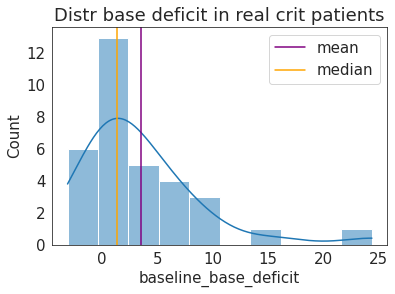

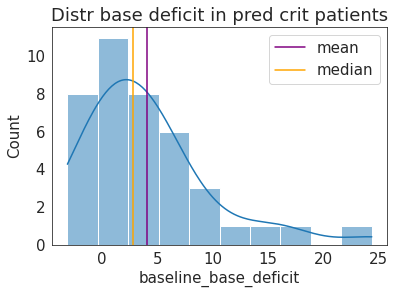

In [158]:
mean= np.mean(clin_crit_r['baseline_base_deficit'])
median=np.median(clin_crit_r['baseline_base_deficit'])
sns.histplot(clin_crit_r.baseline_base_deficit, kde = True)
plt.axvline(x = mean, c = 'purple', label = 'mean')
plt.axvline(x = median, c = 'orange', label = 'median')
plt.title("Distr base deficit in real crit patients")
plt.legend()
plt.show()

mean= np.mean(clin_crit_p['baseline_base_deficit'])
median=np.median(clin_crit_p['baseline_base_deficit'])
sns.histplot(clin_crit_p.baseline_base_deficit, kde = True)
plt.axvline(x = mean, c = 'purple', label = 'mean')
plt.axvline(x = median, c = 'orange', label = 'median')
plt.title("Distr base deficit in pred crit patients")
plt.legend()

In [160]:
clin_descr_p = clin_descr_p.round(1)
clin_descr_r = clin_descr_r.round(1)

In [161]:
# read the infection and mods
# inf_df = pd.read_csv('/Users/smasarone/Desktop/Atom_Trauma/Trauma_ML/PC_notebooks/df_inf_status.csv', header = 0,index_col=0)
# inf_df.columns = ['Inf']
#sofa = pd.read_csv('/Users/smasarone/Downloads/SOMA_SOFA.Trajectories.csv', index_col=0, header=0) #sofa scores trajectories
mods = pd.read_csv('New.MODS.groups(2022).csv', index_col=0, header=0)
mods['MODS.group'].unique()
print("MODS SHAPE:", mods.shape)

MODS SHAPE: (411, 20)


In [162]:
joined=[]
for i in clin_descr_p.T.index:
    joined.append(' ± '.join(clin_descr_p.T.loc[i,:].astype(str)))
    
joined_p = pd.DataFrame(joined)
joined_ = joined_p.T
joined_.columns = clin_descr_p.columns
joined_.index =["Predicted critical"]

join_=[]
for i in clin_descr_r.T.index:
    join_.append(' ± '.join(clin_descr_r.T.loc[i,:].astype(str)))
    
joined_r_ = pd.DataFrame(join_)
joined_r = joined_r_.T
joined_r.columns = clin_descr_r.columns
joined_r.index =["ISS critical >=25 "]

#append them together
final_df_21 = joined_.append(joined_r)
final_df_21.columns = ['Age', 'Injury to baseline time','Admission hr (60-100 bpm)', 'Systolic Blood pressure (<120mmHg)','Baseline wcc (4.5-11 10*9/L)',
       'Baseline lactate (0.5-2.2mmol/L)', 'Baseline base deficit (-2/+2 mEq/L)', 'Length of stay']

In [163]:
final_df_21['Mortality'] = ["6/40(0.15)", "6/33 (0.18)"]
final_df_21['Infection'] = ["11/25 (0.44)" , "8/22 (0.36)"]

# calculate n of infected [patients]
# print(np.bincount(inf_df.filter(items=clin_crit_p.index, axis = 0)["Inf"]))
# print(np.bincount(inf_df.filter(items=clin_crit_r.index, axis = 0)["Inf"]))

In [166]:
mods_pred = mods.filter(items = clin_crit_p.index, axis =0)
mods_real = mods.filter(items = clin_crit_r.index, axis =0)
print(mods_pred['MODS.group'].value_counts())
print(" --- ")
print(mods_real['MODS.group'].value_counts())

final_df_21['Short MODS'] = [5, 5]
final_df_21['Prolonged  MODS'] = [10, 8]
final_df_21['No MODS'] = [19, 14]
final_df_21['Early deaths'] = [4, 4]
final_df_21['Late deaths'] = [2, 2]

NO MODS           19
Prolonged MODS    10
Short MODS         5
Early Death        4
Late Death         2
Name: MODS.group, dtype: int64
 --- 
NO MODS           14
Prolonged MODS     8
Short MODS         5
Early Death        4
Late Death         2
Name: MODS.group, dtype: int64


In [167]:
counts_ = [clin_crit_p.shape[0], clin_crit_r.shape[0]]
count_df= pd.DataFrame(counts_, columns=['Counts'], index =final_df_21.index)

final_df_21 = final_df_21.drop(columns = "Admission hr (60-100 bpm)")
final_dataset = pd.concat([count_df, final_df_21], axis = 1)
final_dataset = final_dataset.drop(columns = 'Injury to baseline time')

In [168]:
final_dataset

,Counts,Age,Systolic Blood pressure (<120mmHg),Baseline wcc (4.5-11 10*9/L),Baseline lactate (0.5-2.2mmol/L),Baseline base deficit (-2/+2 mEq/L),Length of stay,Mortality,Infection,Short MODS,Prolonged MODS,No MODS,Early deaths,Late deaths
Predicted critical,40,42.2 ± 18.2,90.1 ± 22.7,17.4 ± 7.1,3.5 ± 2.5,4.1 ± 5.8,26.1 ± 19.8,6/40(0.15),11/25 (0.44),5,10,19,4,2
ISS critical >=25,33,46.4 ± 19.0,88.3 ± 21.3,15.7 ± 6.6,3.1 ± 2.5,3.5 ± 5.5,30.3 ± 28.5,6/33 (0.18),8/22 (0.36),5,8,14,4,2


In [169]:
import dataframe_image as dfi
final_dataset
dfi.export(final_dataset,"table_pred_vs_real_crit.png")

133906 bytes written to file /var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/tmp2vxrx6op/temp.png
111983 bytes written to file /var/folders/qj/tdp1dq2138jdytx50m9g6p180000gr/T/tmpbar117n9/temp.png


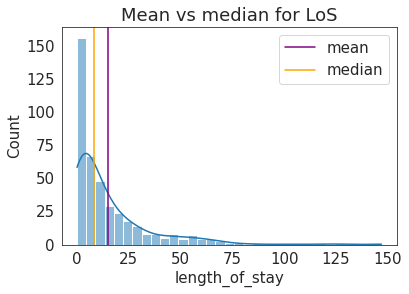

In [170]:
# base def goes up with severity
# lactate goes up with severity
mean= np.mean(clin['length_of_stay'])
median= np.median(clin['length_of_stay'])
sns.histplot(clin['length_of_stay'], kde = True)
plt.axvline(x = mean, c = 'purple', label = 'mean')
plt.axvline(x = median, c = 'orange', label = 'median')
plt.title("Mean vs median for LoS")
plt.legend()
plt.show()

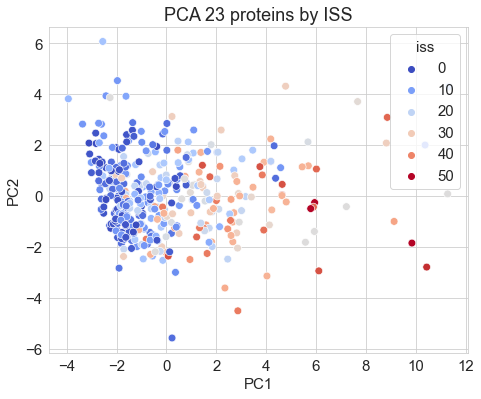

In [173]:
# clustering of proteins
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
X = StandardScaler().fit_transform(prot)
df_scaled_ = pd.DataFrame(X)
df_scaled_.columns = prot.columns
df_scaled_.index = prot.index

list_p = ['PROC.3758.68', 'HIST1H1C.2987.37', 'ASB9.19601.15',
       'CPLX2.15321.8', 'HIST2H2BE.14143.8', 'AFM.4763.31', 'PTH.5954.62',
       'SERPINA7.2706.69', 'RAP2A.9885.41', 'ADSSL1.13998.26',
       'FCN2.13717.15', 'ADSL.5023.23', 'CLIC5.12475.48',
       'ALDH2.18381.16', 'PLTP.15475.4', 'CLEC1B.4332.6', 'TGM3.4471.50',
       'CCL22.3508.78', 'IL1RL1.4234.8', 'UBA2.12500.88',
       'SERPINF1.9211.19', 'IL19.3035.80', 'PDLIM4.12387.7']

sns.set_style("whitegrid")
prot21_ = df_scaled_.filter(items = list_p, axis = 1)
pca = PCA(n_components = 2)
transformed_data = pca.fit_transform(prot21_)
plt.figure(figsize = (7.5,6))
plt.title("PCA 23 proteins by ISS")
plt.xlabel("PC1")
plt.ylabel("PC2")
fig = sns.scatterplot(x = transformed_data[:,0], y = transformed_data[:,1], hue = clin.iss, palette = 'coolwarm', s= 60)
ax.set_xticks(range(12))
fig_path = '/Users/smasarone/Downloads/PCA_23_by_ISS.pdf'
#plt.savefig(fig_path, format=image_format, dpi=1200, bbox_inches='tight')